In [1]:
import torch
import torch.nn as nn
from torch import optim
from dataset import get_dataloader
from model import NGnet
from train import Trainer
import matplotlib.pyplot as plt
from psd import plot_psd_scatter
from statistic_of_errors import evaluate_psd

In [2]:
#Данные
train_dataloader, test_dataloader, (X_val, y_val) = get_dataloader(number_of_samples = 20000, amp_range=(2, 15), length=200, noise_std = 1)
# %%
#Модель
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = NGnet()
model.to(device=device)
loss = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(params=model.parameters(), lr=1e-4)


In [3]:
#тренировка
train_method = Trainer(
        model=model,
        loss=loss,
        optimizer=optimizer,
        device=device,
    )
history_of_train = train_method.fit(
    test_dataloader=test_dataloader,
    train_dataloader=train_dataloader,
    num_epochs=10
)

Эпоха 1/10


100%|██████████| 250/250 [00:01<00:00, 175.20it/s]


torch.Size([64])


100%|██████████| 63/63 [00:00<00:00, 299.99it/s]


torch.Size([32])
TRAIN -> loss: 0.6539357175827026, f1: 0.7878614045364744
VALIDATION -> loss: 0.6122423306344047, f1: 0.9342493055082894, errors: 263
Эпоха 2/10


...

torch.Size([32])
TRAIN -> loss: 0.21204689145088196, f1: 0.9481086509818499
VALIDATION -> loss: 0.2056394335296419, f1: 0.9474829844869738, errors: 210
Эпоха 10/10


100%|██████████| 250/250 [00:01<00:00, 221.53it/s]


torch.Size([64])


100%|██████████| 63/63 [00:00<00:00, 375.59it/s]

torch.Size([32])
TRAIN -> loss: 0.19472183191776277, f1: 0.9492368007750265
VALIDATION -> loss: 0.1908944428913177, f1: 0.9477325916863185, errors: 209


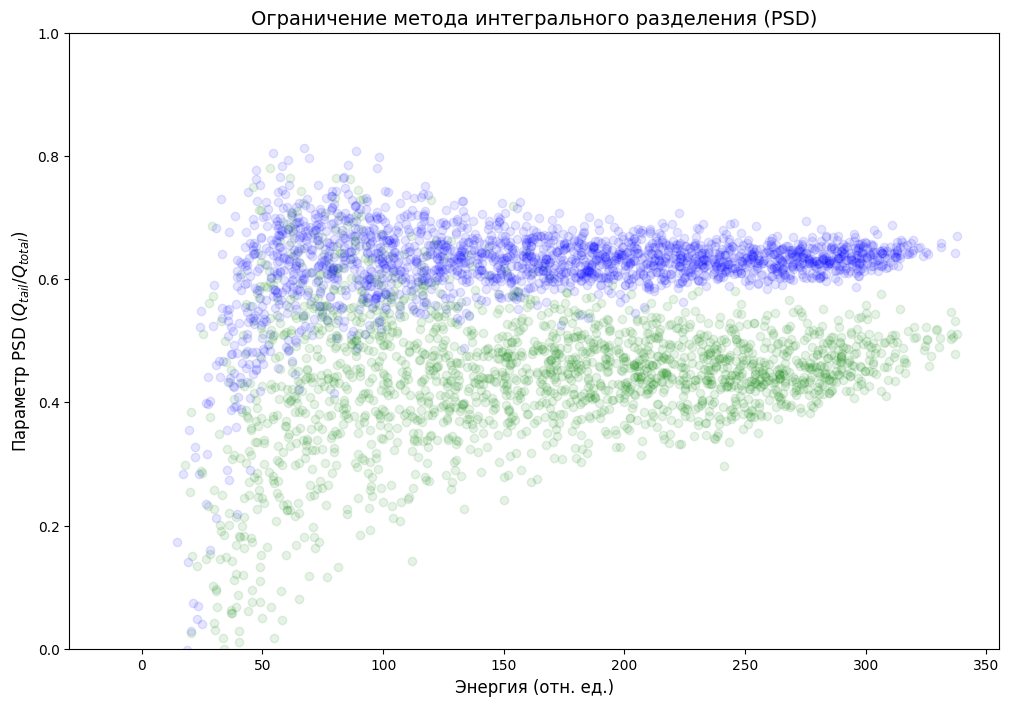

In [4]:

#Отрисовка
plot_psd_scatter(X=X_val, start_time=20, tail_time=30, y=y_val)
    

Количество ошибок PSD 462


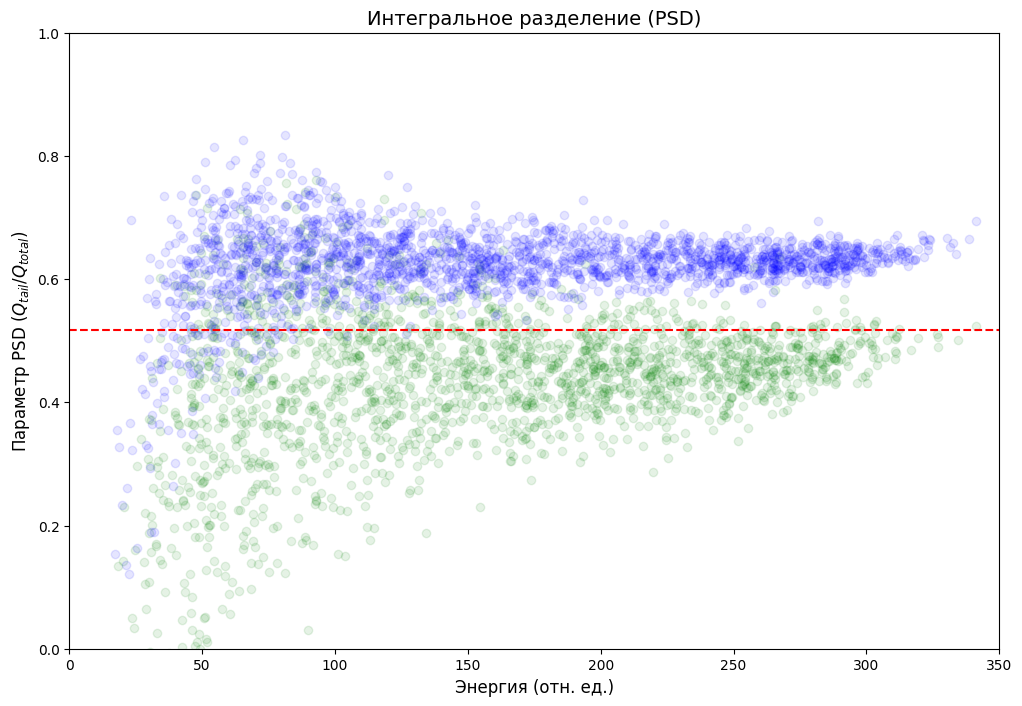

In [5]:
#PSD
min_errors, best_treshold = evaluate_psd(X_val, y_val)